Train size: 2048, Val size: 440, Test size: 440
Number of features (nx): 202
Model 1 params: 13057
Model 2 params: 15105
Training Model 1...
Training Model 2...
Advanced Model params: 36737
Training Advanced Model...

--- Test Results ---
Model 1 (1 Hidden): MSE=3.55, RMSE=1.88, R2=0.9570
Model 2 (2 Hidden): MSE=4.02, RMSE=2.01, R2=0.9513
Advanced Model:     MSE=3.57, RMSE=1.89, R2=0.9567


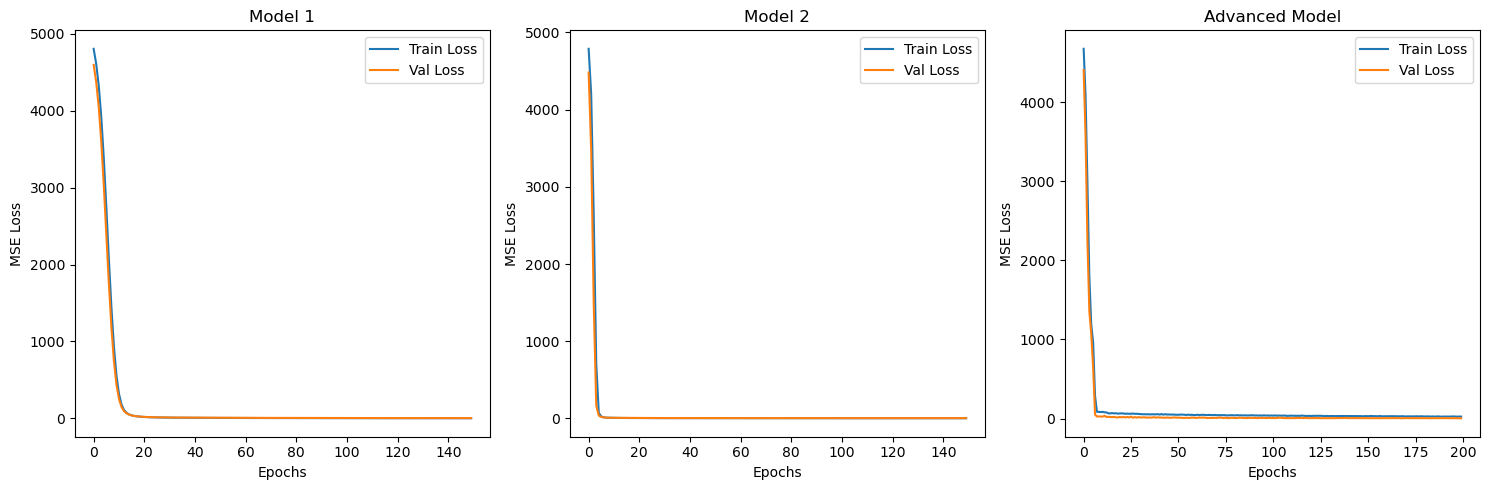

In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# ==========================================
# 1. Preprocessing
# ==========================================

df = pd.read_csv('./Life Expectancy Data/Life Expectancy Data.csv')

# Column names may have leading/trailing spaces, we fix them
df.columns = df.columns.str.strip()

# Handle missing values in target variable
df.dropna(subset=['Life expectancy'], inplace=True)

y = df['Life expectancy'].values
X = df.drop(['Life expectancy'], axis=1)

# Convert categorical variables to numeric (One-Hot Encoding)
X = pd.get_dummies(X, columns=['Country', 'Status'], drop_first=True)

# Handle missing values in features using median
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

X_temp, X_test, y_temp, y_test = train_test_split(X_imputed, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, random_state=42)

print(f"Train size: {X_train.shape[0]}, Val size: {X_val.shape[0]}, Test size: {X_test.shape[0]}")
print(f"Number of features (nx): {X_train.shape[1]}")

# Data normalization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

# Create DataLoader
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

input_dim = X_train_t.shape[1]

# ==========================================
# 2. Simple Neural Networks
# ==========================================

# Model 1: One hidden layer
class Model1(nn.Module):
    def __init__(self, input_dim):
        super(Model1, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x)

# Model 2: Two hidden layers
class Model2(nn.Module):
    def __init__(self, input_dim):
        super(Model2, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

model1 = Model1(input_dim)
model2 = Model2(input_dim)
print(f"Model 1 params: {count_parameters(model1)}")
print(f"Model 2 params: {count_parameters(model2)}")

def train_and_evaluate(model, epochs=150, lr=0.001):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    train_losses = []
    val_losses = []
    
    for epoch in range(epochs):
        model.train()
        batch_losses = []
        for X_b, y_b in train_loader:
            optimizer.zero_grad()
            preds = model(X_b)
            loss = criterion(preds, y_b)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())
            
        train_losses.append(np.mean(batch_losses))
        
        model.eval()
        with torch.no_grad():
            val_preds = model(X_val_t)
            val_loss = criterion(val_preds, y_val_t).item()
            val_losses.append(val_loss)
            
    # Compute test metrics
    model.eval()
    with torch.no_grad():
        test_preds = model(X_test_t).numpy()
        test_actuals = y_test_t.numpy()
        
    mse = mean_squared_error(test_actuals, test_preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(test_actuals, test_preds)
    
    return train_losses, val_losses, mse, rmse, r2

print("Training Model 1...")
t_loss1, v_loss1, mse1, rmse1, r2_1 = train_and_evaluate(model1)
print("Training Model 2...")
t_loss2, v_loss2, mse2, rmse2, r2_2 = train_and_evaluate(model2)

# ==========================================
# 3. Advanced Neural Network
# ==========================================

class AdvancedModel(nn.Module):
    def __init__(self, input_dim):
        super(AdvancedModel, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.3),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.2),
            
            nn.Linear(64, 32),
            nn.LeakyReLU(0.1),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x)

advanced_model = AdvancedModel(input_dim)
print(f"Advanced Model params: {count_parameters(advanced_model)}")
print("Training Advanced Model...")

optimizer = optim.AdamW(advanced_model.parameters(), lr=0.001, weight_decay=1e-4)

t_loss3, v_loss3, mse3, rmse3, r2_3 = train_and_evaluate(advanced_model, epochs=200)

# ==========================================
# 4. Results Print
# ==========================================

print("\n--- Test Results ---")
print(f"Model 1 (1 Hidden): MSE={mse1:.2f}, RMSE={rmse1:.2f}, R2={r2_1:.4f}")
print(f"Model 2 (2 Hidden): MSE={mse2:.2f}, RMSE={rmse2:.2f}, R2={r2_2:.4f}")
print(f"Advanced Model:     MSE={mse3:.2f}, RMSE={rmse3:.2f}, R2={r2_3:.4f}")

# Plot graphs
plt.figure(figsize=(15, 5))
models_losses = [(t_loss1, v_loss1, "Model 1"), (t_loss2, v_loss2, "Model 2"), (t_loss3, v_loss3, "Advanced Model")]

for i, (t_loss, v_loss, title) in enumerate(models_losses):
    plt.subplot(1, 3, i+1)
    plt.plot(t_loss, label='Train Loss')
    plt.plot(v_loss, label='Val Loss')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss')
    plt.legend()

plt.tight_layout()
plt.savefig("changes_MSE_loss.png", dpi=300)
plt.show()